# Italian Renewable Power Market Analysis

This notebook explores the Italian Day-Ahead electricity market as the foundation for a short-term renewable power trading simulation.

The analysis focuses on the PUN Index GME, the national reference price for the Italian Day-Ahead market. The goal is to identify the main price patterns that affect the revenues and decisions of a short-term renewable power trader managing a photovoltaic portfolio.

In particular, this notebook investigates:

- hourly electricity price dynamics
- seasonal electricity price patterns
- price volatility and extreme market events
- market characteristics relevant for renewable energy trading

This notebook represents the first step toward a full trading workflow including renewable generation forecasting, Day-Ahead positioning, Intraday rebalancing, and PnL analysis.

## Configuration

In [1]:
# =========================
# Project configuration
# =========================

COUNTRY = "Italy"
MARKET = "Day-Ahead"
ASSET_TYPE = "Solar PV"

START_DATE = "2023-01-01"
END_DATE = "2023-12-31"

RAW_DATA_DIR = "../data/raw"
PROCESSED_DATA_DIR = "../data/processed"

OUTPUT_FILE = "../data/processed/italian_market_prices_2023.csv"

## Imports

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append("..")

from src.data_loader import (
    load_gme_price_sheet,
    prepare_market_prices
)
from src.metrics import quality_report

## Create Project Data Folders

The project stores raw and processed datasets in separate directories.

- `data/raw` contains original downloaded datasets
- `data/processed` contains cleaned and transformed data used throughout the project

This structure improves reproducibility and keeps the data pipeline organized.

In [3]:
# create data directories if they do not already exist
Path(RAW_DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(PROCESSED_DATA_DIR).mkdir(parents=True, exist_ok=True)

print("Data folders are ready.")

Data folders are ready.


## Data Sources

This analysis uses historical electricity price data from the Italian Day-Ahead Market (MGP), operated by Gestore dei Mercati Energetici (GME).

The PUN Index GME is selected as the reference price series because it represents the national benchmark for electricity traded in the Italian Day-Ahead market.

The resulting dataset provides an hourly view of electricity prices throughout 2023 and serves as the foundation for the forecasting and trading analyses developed in the subsequent notebooks.

## Load Market Data

The historical GME dataset is loaded from the project data directory and prepared for analysis.

The dataset is distributed as a compressed archive containing multiple worksheets and market indicators. For this study, only the hourly Day-Ahead price data are extracted.

In [4]:
# locate GME historical dataset
zip_path = Path(RAW_DATA_DIR) / "Anno2023.zip"

print(f"Selected file: {zip_path.name}")

Selected file: Anno2023.zip


## Load Market Prices

The hourly Day-Ahead electricity prices are extracted from the GME historical dataset.

The analysis focuses on the PUN Index GME, which serves as the national benchmark electricity price and represents the market environment in which a renewable energy trader operates.

These prices form the economic basis for the forecasting and trading analyses developed throughout the project.

In [5]:
prices_df = load_gme_price_sheet(zip_path)

prices_df.head()

,Data/Date\n(YYYYMMDD),Ora\n/Hour,PUN,AUST,BSP,CALA,CNOR,COAC,CORS,CSUD,...,MONT,NORD,SARD,SICI,SLOV,SUD,SVIZ,XAUS,XFRA,XGRE
0,20230101,1,195.90,195.90,195.90,195.90,195.90,195.90,195.90,195.90,...,195.90,195.90,195.90,195.90,195.90,195.90,195.90,195.90,195.90,195.90
1,20230101,2,191.09,191.09,191.09,191.09,191.09,191.09,191.09,191.09,...,191.09,191.09,191.09,191.09,191.09,191.09,191.09,191.09,191.09,191.09
2,20230101,3,187.95,187.95,187.95,187.95,187.95,187.95,187.95,187.95,...,187.95,187.95,187.95,187.95,187.95,187.95,187.95,187.95,187.95,187.95
3,20230101,4,187.82,187.82,187.82,187.82,187.82,187.82,187.82,187.82,...,187.82,187.82,187.82,187.82,187.82,187.82,187.82,187.82,187.82,187.82
4,20230101,5,187.74,187.74,187.74,187.74,187.74,187.74,187.74,187.74,...,187.74,187.74,187.74,187.74,187.74,187.74,187.74,187.74,187.74,187.74


## Data Preparation

The original GME dataset contains several market zones and cross-border areas.

For this analysis, only the national reference price (PUN Index GME) is retained, as it represents the benchmark electricity price used throughout the Italian market.

The date and hour information are combined into a single timestamp to create a clean hourly time series suitable for exploratory analysis, forecasting, and trading simulations.

In [6]:
market_df = prepare_market_prices(prices_df)

market_df.head()

,datetime,price
0,2023-01-01 00:00:00,195.90
1,2023-01-01 01:00:00,191.09
2,2023-01-01 02:00:00,187.95
3,2023-01-01 03:00:00,187.82
4,2023-01-01 04:00:00,187.74


## Data Quality Checks

Before performing the analysis, basic quality checks are applied to verify data completeness and detect missing values.

In [7]:
quality_report(market_df)

Rows: 8760

Missing values:
datetime    0
price       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  8760 non-null   datetime64[ns]
 1   price     8760 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 137.0 KB


## Market Statistics

Understanding the distribution of electricity prices is an important first step in market analysis.

Electricity markets are characterized by high volatility and occasional price spikes. Examining the distribution helps identify typical market conditions and extreme events that may affect trading performance.

Basic descriptive statistics provide an initial overview of price levels, variability, and the range of observed market conditions.

In [8]:
market_df["price"].describe()

count    8760.000000
mean      127.236963
std        35.586747
min         2.456320
25%       104.870000
50%       122.036295
75%       146.550000
max       295.000000
Name: price, dtype: float64

## Hourly Price Time Series

The hourly PUN Index is visualized over the entire year to identify market regimes, seasonal patterns, and periods of elevated volatility.

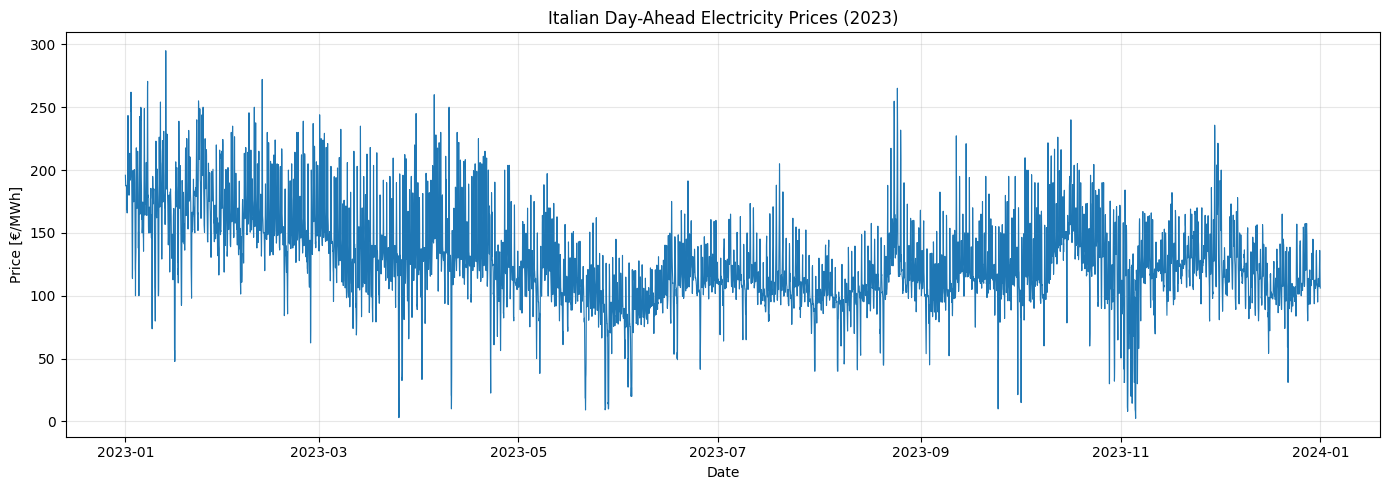

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(
    market_df["datetime"],
    market_df["price"],
    linewidth=0.8
)
plt.title("Italian Day-Ahead Electricity Prices (2023)")
plt.xlabel("Date")
plt.ylabel("Price [€/MWh]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Market Insight

The Italian Day-Ahead electricity market exhibited substantial price volatility throughout 2023, with hourly prices ranging from approximately 2 €/MWh to 295 €/MWh.

Price levels were particularly elevated during the winter months, reflecting the lingering effects of the European energy crisis and tighter market conditions. In contrast, significantly lower prices were observed during spring and early summer periods.

For renewable energy traders, this variability directly affects portfolio revenues, as both generation volumes and market timing determine the economic value of renewable production.

Understanding these price dynamics is therefore essential for revenue forecasting, market exposure assessment, and short-term trading decisions.


## Average Hourly Price Profile

Electricity prices are strongly influenced by daily consumption patterns.

Analyzing the average price for each hour of the day helps identify recurring market structures that are relevant for renewable generation and trading decisions.

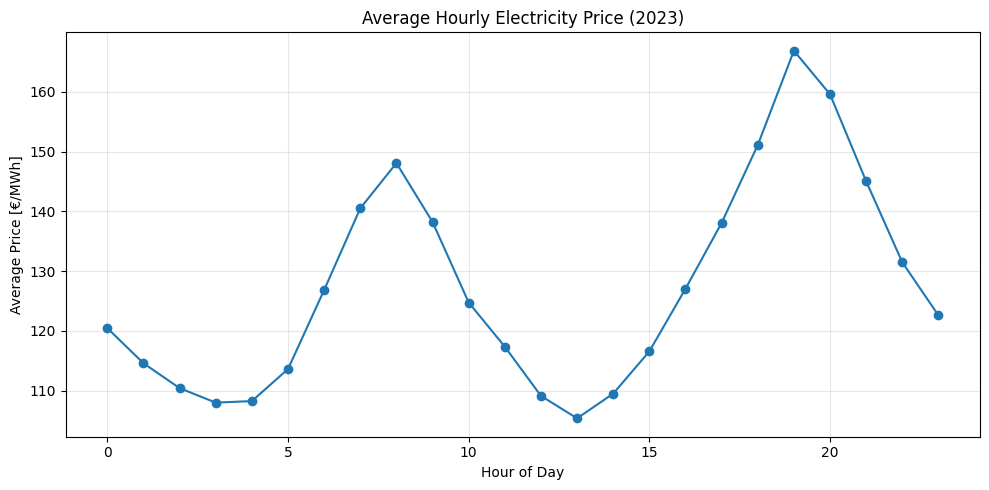

In [10]:
# extract hour
market_df["hour"] = market_df["datetime"].dt.hour

hourly_profile = (
    market_df
    .groupby("hour")["price"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_profile.index,
    hourly_profile.values,
    marker="o"
)
plt.title("Average Hourly Electricity Price (2023)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price [€/MWh]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Trading Implication

A pronounced intraday price structure emerges from the analysis.

Average prices are lowest around midday, when photovoltaic generation is typically at its highest, and peak during the evening hours when solar production rapidly declines while electricity demand remains elevated.

This pattern illustrates the well-known solar cannibalization effect, whereby large amounts of solar generation tend to depress market prices during production peaks.

For renewable energy traders, accurately forecasting both generation and market conditions is therefore essential to maximize portfolio value.

## Average Monthly Price Profile

Electricity prices are also influenced by seasonal effects, including weather conditions, electricity demand, fuel costs, and renewable generation patterns.

Analyzing average monthly prices helps identify seasonal market regimes and understand how the economic value of renewable generation changes throughout the year.

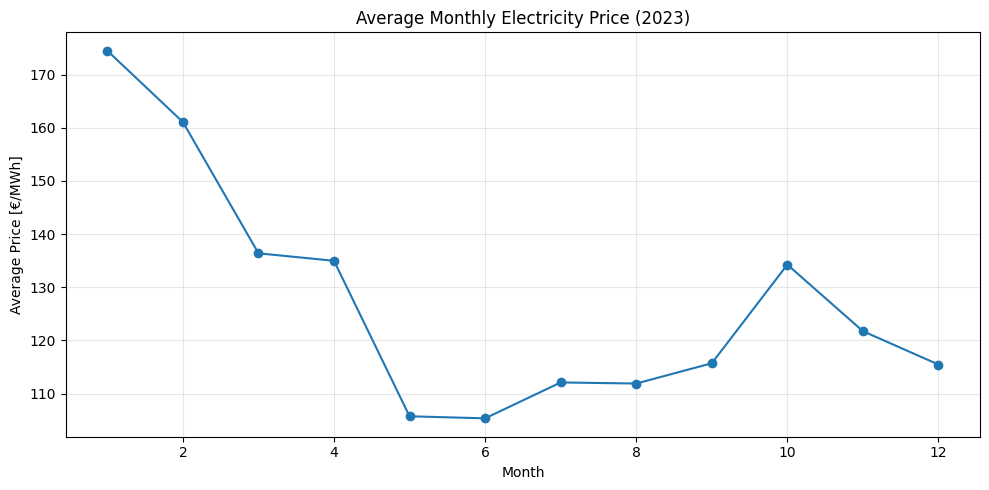

In [11]:
# extract month
market_df["month"] = market_df["datetime"].dt.month

monthly_profile = (
    market_df
    .groupby("month")["price"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_profile.index,
    monthly_profile.values,
    marker="o"
)
plt.title("Average Monthly Electricity Price (2023)")
plt.xlabel("Month")
plt.ylabel("Average Price [€/MWh]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Seasonal Insight

Electricity prices exhibit strong seasonal variability throughout 2023.

The highest average prices occurred during the winter months, particularly January and February, while the lowest prices were observed during late spring and early summer.

This seasonal pattern reflects changing market fundamentals, including weather conditions, renewable generation availability, and electricity demand.

As a result, the economic value of renewable generation can vary substantially across the year, even when production volumes remain similar.

## Price Distribution

Electricity markets are characterized by high volatility and occasional extreme events.

Analyzing the distribution of prices helps identify the most common market conditions and assess the frequency of unusually high or low prices.

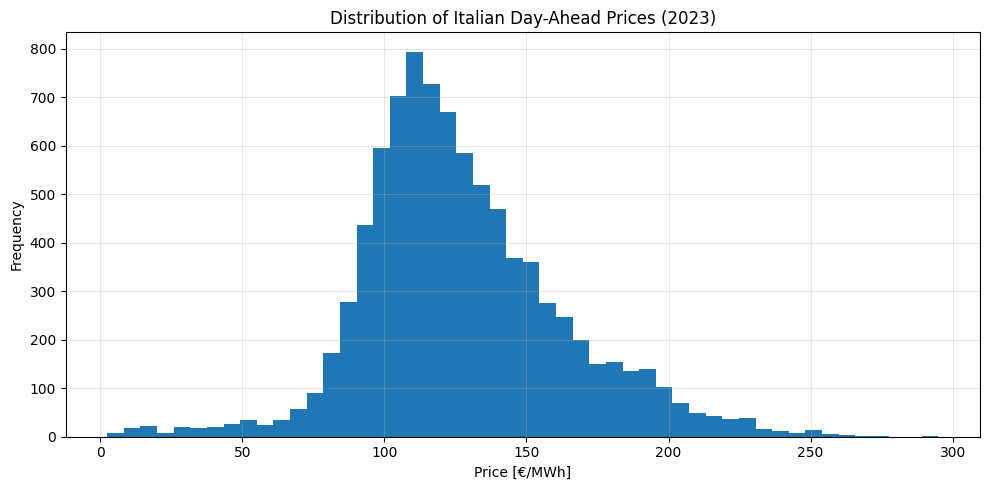

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(
    market_df["price"],
    bins=50
)
plt.title("Distribution of Italian Day-Ahead Prices (2023)")
plt.xlabel("Price [€/MWh]")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Market Insight

Most electricity prices were concentrated between approximately 90 and 150 €/MWh, representing typical market conditions during 2023.

However, the distribution exhibits a pronounced right tail, indicating the presence of occasional price spikes above 250 €/MWh. A small number of near-zero price events are also visible.

These extreme market conditions are particularly relevant for renewable energy traders because a limited number of hours can contribute disproportionately to annual revenues and portfolio risk.

## Extreme Price Events

Periods of unusually high or low prices are especially important for renewable energy traders, as they can significantly affect portfolio revenues and market exposure.

In [13]:
print("Highest prices")

market_df.nlargest(
    10,
    "price"
)[["datetime", "price"]]

Highest prices


,datetime,price
296,2023-01-13 08:00:00,295.00000
1003,2023-02-11 19:00:00,272.15507
163,2023-01-07 19:00:00,270.60731
162,2023-01-07 18:00:00,266.41638
5658,2023-08-24 19:00:00,265.13149
41,2023-01-02 17:00:00,262.00000
2263,2023-04-05 08:00:00,260.00000
536,2023-01-23 08:00:00,255.06220
5635,2023-08-23 20:00:00,254.81012
5634,2023-08-23 19:00:00,254.72873


In [14]:
print("Lowest prices")

market_df.nsmallest(
    10,
    "price"
)[["datetime", "price"]]

Lowest prices


,datetime,price
7406,2023-11-05 14:00:00,2.45632
7405,2023-11-05 13:00:00,2.99127
2005,2023-03-25 13:00:00,3.02237
2006,2023-03-25 14:00:00,4.27098
2007,2023-03-25 15:00:00,4.74602
7404,2023-11-05 12:00:00,7.74593
7347,2023-11-03 03:00:00,8.00000
7403,2023-11-05 11:00:00,8.17778
3372,2023-05-21 13:00:00,9.10137
3516,2023-05-27 13:00:00,9.22000


### Trading Implication

The highest electricity prices were concentrated primarily during winter periods and evening peak-demand hours, when renewable generation availability is relatively limited.

Conversely, the lowest prices occurred predominantly during midday hours in spring and autumn, coinciding with periods of strong solar generation.

This pattern highlights a key challenge for photovoltaic portfolios: production tends to be highest precisely when electricity prices are often under downward pressure.

Consequently, forecasting accuracy and effective market positioning become critical drivers of portfolio value.

## Price Volatility Summary

To quantify the magnitude of price variability in the Italian Day-Ahead market, a set of summary statistics is computed.

The price spread between the highest and lowest observed prices provides a simple measure of market volatility and highlights the potential economic impact of forecasting and trading decisions.

In [15]:
print(f"Average price: {market_df['price'].mean():.2f} €/MWh")
print(f"Maximum price: {market_df['price'].max():.2f} €/MWh")
print(f"Minimum price: {market_df['price'].min():.2f} €/MWh")

spread = market_df["price"].max() - market_df["price"].min()
print(f"Price spread: {spread:.2f} €/MWh")

Average price: 127.24 €/MWh
Maximum price: 295.00 €/MWh
Minimum price: 2.46 €/MWh
Price spread: 292.54 €/MWh


### Market Significance

The Italian Day-Ahead market exhibited substantial price variability throughout 2023.

While the average market price was approximately 127 €/MWh, hourly prices ranged from about 2 €/MWh to 295 €/MWh, resulting in an annual price spread of nearly 293 €/MWh.

This wide range highlights the highly dynamic nature of electricity markets and demonstrates how the economic value of renewable generation can vary significantly depending on the timing of production.

For renewable energy traders, such volatility creates both risks and opportunities. Accurate generation forecasts and effective market positioning can substantially improve portfolio revenues, particularly during periods of elevated prices or unusual market conditions.

These observations provide a strong motivation for developing forecasting models and short-term trading strategies, which are explored in the following notebooks.

---

## Key Findings

The analysis of the Italian Day-Ahead electricity market in 2023 highlights several important patterns:

1. Electricity prices were highly volatile, ranging from approximately 2 €/MWh to 295 €/MWh, with an average annual price of about 127 €/MWh.

2. A pronounced intraday structure exists, with the highest average prices occurring during the evening peak hours and the lowest prices occurring around midday.

3. The midday price depression coincides with typical photovoltaic production peaks, illustrating a clear solar cannibalization effect.

4. Significant seasonal variation is observed throughout the year, with winter months exhibiting substantially higher prices than spring and early summer.

5. Extreme price events are concentrated in specific market conditions: the highest prices occur mainly during winter peak-demand periods, while the lowest prices occur during midday hours characterized by strong renewable generation.

6. The annual price spread reached approximately 293 €/MWh, highlighting the potential economic value of accurate forecasting and effective short-term trading decisions.

These findings demonstrate that the timing of renewable generation is just as important as the amount of energy produced. Consequently, forecasting accuracy and active market participation can play a crucial role in maximizing portfolio revenues.

The insights obtained in this notebook provide the foundation for the renewable generation forecasting and trading analyses developed in the following stages of the project.

## Save Clean Dataset

The cleaned hourly price series is exported for use in the renewable generation forecasting and trading simulations developed in the subsequent notebooks.

In [16]:
market_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Dataset saved to {OUTPUT_FILE}")

Dataset saved to ../data/processed/italian_market_prices_2023.csv
